# Continuous Flow Matching (unconditional, QM9 / ZINC)

Pipeline: **train → sample → VUN**.

## Setup

In [1]:
import os

REPO = "flow-matching-molecules"
if not os.path.isdir(REPO):
    !git clone https://github.com/Nico-Conti/flow-matching-molecules.git
os.chdir(REPO if os.path.basename(os.getcwd()) != REPO else ".")

!pip install -q uv
!uv pip install --system -q -e .   # installs deps + the package from pyproject
import sys; sys.path.insert(0, os.path.abspath("src"))  # flat src/ layout
print("cwd:", os.getcwd())

Cloning into 'flow-matching-molecules'...
remote: Enumerating objects: 98, done.
remote: Counting objects: 100% (98/98), done.
remote: Compressing objects: 100% (75/75), done.
remote: Total 98 (delta 38), reused 81 (delta 21), pack-reused 0 (from 0)
Receiving objects: 100% (98/98), 560.39 KiB | 2.43 MiB/s, done.
Resolving deltas: 100% (38/38), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 49.9 MB/s eta 0:00:00
cwd: /content/flow-matching-molecules


In [2]:
import torch
import train, evaluate
print(torch.__version__, "cuda:", torch.cuda.is_available())

2.11.0+cu128 cuda: True


/usr/local/lib/python3.12/dist-packages/torch_molecule/generator/molgpt/modeling_molgpt.py:112: SyntaxWarning: invalid escape sequence '\['
  self.pattern = "(\[[^\]]+]|<|Br?|Cl?|N|O|S|P|F|I|b|c|n|o|s|p|\(|\)|\.|=|#|-|\+|\\\\|\/|:|~|@|\?|>|\*|\$|\%[0-9]{2}|[0-9])"


## Reload a saved checkpoint (skip training)
Load a trained model without retraining. `which="final"` (default) loads the
last checkpoint; `which="best"` loads the lowest-val-loss checkpoint.

In [ ]:
import os
import matplotlib.pyplot as plt
from checkpoint import repo_to_path, best_path, load_checkpoint, load_checkpoint_from_hf

repo  = "nico8771/qm9_stage1_fm"
which = "final"                      # "final" or "best"

local = repo_to_path(repo)
if which == "best":
    local = best_path(local)
fname = os.path.basename(local)

ck = load_checkpoint(local) if os.path.exists(local) else load_checkpoint_from_hf(repo, fname)

model        = ck["model"]
history      = ck["history"]
size_sampler = ck["size_sampler"]
train_smiles = ck["train_smiles"]
atom_vocab   = ck["atom_vocab"]
k_X, k_E     = ck["k_X"], ck["k_E"]
print(f"loaded {which} checkpoint (epoch {ck['epoch']}, best_val={ck['extra'].get('best_val')})")

# Plot loss from the reloaded history.
plt.figure(figsize=(8, 4))
plt.semilogy(history["step"], history["loss"], label="train (total)", lw=1.5)
n_epochs = len(history["val_loss"])
if n_epochs > 0:
    spe = max(len(history["step"]) // n_epochs, 1)
    val_x = [(e + 1) * spe - 1 for e in range(n_epochs)]
    plt.semilogy(val_x, history["val_loss"], "o-", label="val (total)", lw=1.5, ms=5)
plt.xlabel("step"); plt.ylabel("loss (log)"); plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.title(f"Reloaded {which} checkpoint - loss")
plt.show()


## QM9 — Train
Auto-resumes from the last checkpoint and pushes checkpoints to `push_repo`
(local path is implicit). `save_every` is the checkpoint cadence in epochs.

In [4]:
(model, history, size_sampler, train_smiles, atom_vocab,
 k_X, k_E, test_smiles) = train.train(
    epochs=25, batch_size=128, subset=None, dataset="qm9",
    push_repo="nico8771/qm9_fm", save_every=1)

epoch 0 step 0 loss 3.8008 loss_x 2.4859 loss_e 1.3149 lr 5.00e-04
epoch 0 step 50 loss 0.6231 loss_x 0.3509 loss_e 0.2722 lr 5.00e-04
epoch 0 step 100 loss 0.5612 loss_x 0.3203 loss_e 0.2410 lr 5.00e-04
epoch 0 step 150 loss 0.4201 loss_x 0.2487 loss_e 0.1714 lr 5.00e-04
epoch 0 step 200 loss 0.4355 loss_x 0.2676 loss_e 0.1679 lr 5.00e-04
epoch 0 step 250 loss 0.4174 loss_x 0.2572 loss_e 0.1602 lr 5.00e-04
epoch 0 step 300 loss 0.3973 loss_x 0.2522 loss_e 0.1452 lr 5.00e-04
epoch 0 step 350 loss 0.3906 loss_x 0.2241 loss_e 0.1665 lr 5.00e-04
epoch 0 step 400 loss 0.3692 loss_x 0.2198 loss_e 0.1494 lr 5.00e-04
epoch 0 step 450 loss 0.3532 loss_x 0.2053 loss_e 0.1479 lr 5.00e-04
epoch 0 step 500 loss 0.3513 loss_x 0.2170 loss_e 0.1343 lr 5.00e-04
epoch 0 step 550 loss 0.3932 loss_x 0.2392 loss_e 0.1540 lr 5.00e-04
epoch 0 step 600 loss 0.3640 loss_x 0.2202 loss_e 0.1438 lr 5.00e-04
epoch 0 step 650 loss 0.3448 loss_x 0.2037 loss_e 0.1411 lr 5.00e-04
epoch 0 step 700 loss 0.3352 loss_x 0

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  checkpoints/qm9_fm_best.pt  :   1%|1         |  574kB / 56.1MB            

  best saved -> checkpoints/qm9_fm_best.pt (epoch 0) + pushed to nico8771/qm9_fm


...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  checkpoints/qm9_fm.pt       : 100%|##########| 56.7MB / 56.7MB            

No files have been modified since last commit. Skipping to prevent empty commit.


  final saved -> checkpoints/qm9_fm.pt (epoch 24) + pushed to nico8771/qm9_fm


## QM9 — Loss curves


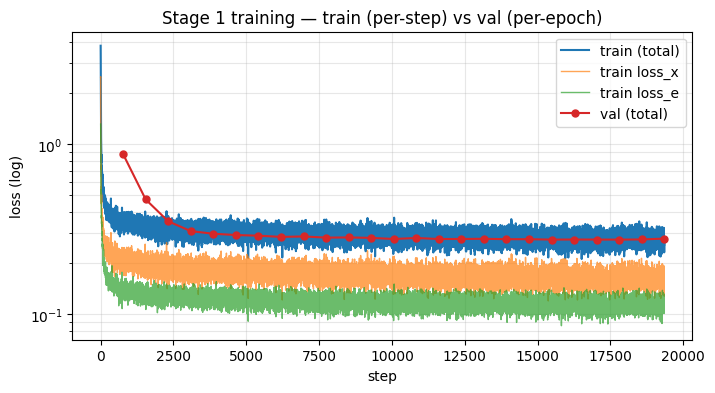

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.semilogy(history["step"], history["loss"],   label="train (total)", lw=1.5)
plt.semilogy(history["step"], history["loss_x"], label="train loss_x", lw=1, alpha=0.7)
plt.semilogy(history["step"], history["loss_e"], label="train loss_e", lw=1, alpha=0.7)
# val_loss is per-epoch; anchor each marker at the last training step of its epoch.
n_epochs = len(history["val_loss"])
if n_epochs > 0:
    steps_per_epoch = max(len(history["step"]) // n_epochs, 1)
    val_x = [(e + 1) * steps_per_epoch - 1 for e in range(n_epochs)]
    plt.semilogy(val_x, history["val_loss"], "o-", label="val (total)", lw=1.5, ms=5)
plt.xlabel("step")
plt.ylabel("loss (log)")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.title("Stage 1 training — train (per-step) vs val (per-epoch)")
plt.show()


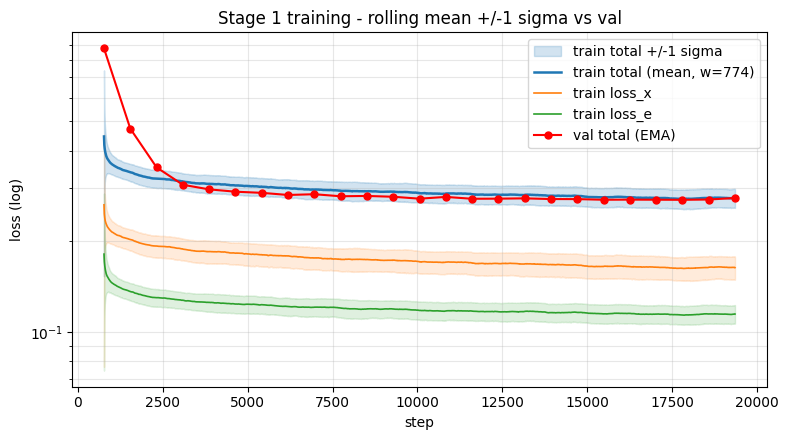

Final rolling-window values (w = 774 steps = 1 epoch)
  train total      loss=0.2782   std=0.0201   sigma/mu=7.23%
  train loss_x     loss=0.1635   std=0.0144   sigma/mu=8.78%
  train loss_e     loss=0.1147   std=0.0081   sigma/mu=7.07%
  val total (EMA)  loss=0.2785


In [6]:
import numpy as np
import matplotlib.pyplot as plt

def rolling_stats(y, w):
    # Right-aligned rolling mean and std over window w; length len(y)-w+1.
    y = np.asarray(y, dtype=float)
    mean = np.convolve(y, np.ones(w) / w, mode="valid")
    mean_sq = np.convolve(y * y, np.ones(w) / w, mode="valid")
    var = np.clip(mean_sq - mean ** 2, 0.0, None)   # clip tiny FP negatives
    return mean, np.sqrt(var)

n_epochs = len(history["val_loss"])
steps_per_epoch = max(len(history["step"]) // max(n_epochs, 1), 1)
w = steps_per_epoch                          # 1-epoch smoothing window
steps = np.asarray(history["step"])
x_roll = steps[w - 1:]

mean_tot, std_tot = rolling_stats(history["loss"],   w)
mean_x,   std_x   = rolling_stats(history["loss_x"], w)
mean_e,   std_e   = rolling_stats(history["loss_e"], w)

# --- Loss: rolling mean +/-1 sigma vs val ----------------------------------
plt.figure(figsize=(8, 4.5))
plt.fill_between(x_roll, np.clip(mean_tot - std_tot, 1e-6, None), mean_tot + std_tot,
                 color="C0", alpha=0.20, label="train total +/-1 sigma")
plt.fill_between(x_roll, np.clip(mean_x - std_x, 1e-6, None), mean_x + std_x,
                 color="C1", alpha=0.15)
plt.fill_between(x_roll, np.clip(mean_e - std_e, 1e-6, None), mean_e + std_e,
                 color="C2", alpha=0.15)
plt.semilogy(x_roll, mean_tot, color="C0", lw=1.8, label=f"train total (mean, w={w})")
plt.semilogy(x_roll, mean_x,   color="C1", lw=1.2, label="train loss_x")
plt.semilogy(x_roll, mean_e,   color="C2", lw=1.2, label="train loss_e")
if n_epochs > 0:
    val_x = [(e + 1) * steps_per_epoch - 1 for e in range(n_epochs)]
    plt.semilogy(val_x, history["val_loss"], "o-", color="red", lw=1.5, ms=5,
                 label="val total (EMA)")
plt.xlabel("step")
plt.ylabel("loss (log)")
plt.title("Stage 1 training - rolling mean +/-1 sigma vs val")
plt.legend(loc="upper right")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# --- Std and loss values (final rolling window) ----------------------------
def _fmt(label, mean, std):
    cv = std / mean if mean > 0 else float("nan")
    print(f"  {label:<16} loss={mean:.4f}   std={std:.4f}   sigma/mu={cv:.2%}")

print(f"Final rolling-window values (w = {w} steps = 1 epoch)")
print("=" * 52)
_fmt("train total",  mean_tot[-1], std_tot[-1])
_fmt("train loss_x", mean_x[-1],   std_x[-1])
_fmt("train loss_e", mean_e[-1],   std_e[-1])
if n_epochs > 0:
    print(f"  {'val total (EMA)':<16} loss={history['val_loss'][-1]:.4f}")


## QM9 — Evaluate (V/U/N)

In [11]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
vun = evaluate.evaluate(model, size_sampler, train_smiles, atom_vocab,
                        k_X, k_E, n_samples=1000, batch=256, steps=100,
                        device=device)
print(vun)

{'validity': 0.819, 'uniqueness': 0.9816849816849816, 'novelty': 0.6840796019900498, 'n_generated': 1000, 'n_valid': 819, 'n_unique': 804, 'n_novel': 550, 'repair_rate': 0.0}


## QM9 — Generated molecules (visual sample)


  0: CCC1CC2(CC2C)O1
  1: C1CC2CC3(CO3)C2C1
  2: OCCN1CC1C1CC1
  3: N#CCC1=NCN1C=O
  4: CC1C(C)N2C(C)C12
  5: CC1=NOC(C)N=NO1
  6: COC12CCCC1C2
  7: CCCC(CC)OC=O
  8: CN=CC(C)COC=N
  9: N#CCC=CO
  10: CC(C)=CC(C)C(N)=O
  11: N#CC(=O)N=CC1CC1 (rep)


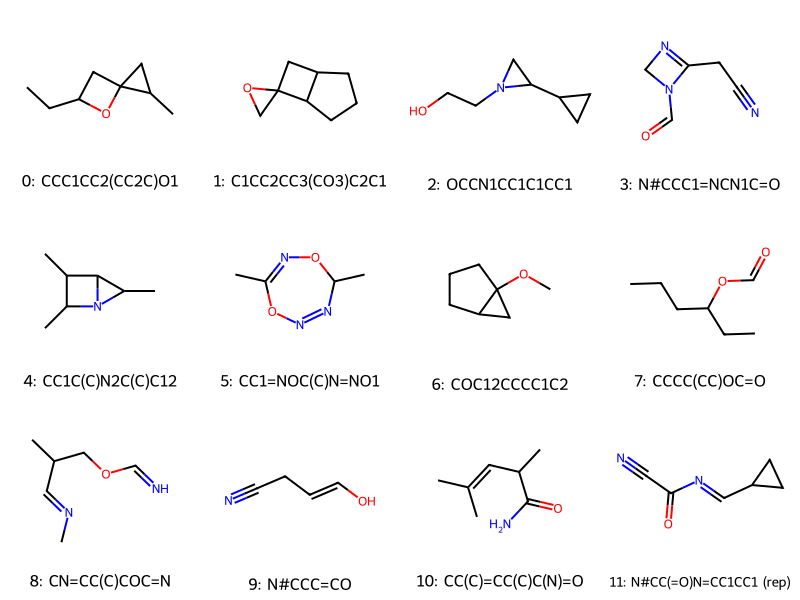

In [ ]:
import torch
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display
from dataset.featurize import tensor_to_mol, largest_fragment
from flow import sample

n_show = 12
n_list = size_sampler.sample(n_show)
with torch.no_grad():
    X_oh, E_oh, mask = sample(model, n_list, k_X, k_E, steps=100, device=device)

mols, legends = [], []
for i in range(n_show):
    n = int(mask[i].sum().item())
    m, was_repaired = tensor_to_mol(X_oh[i, :n].cpu(), E_oh[i, :n, :n].cpu(), atom_vocab)
    m = largest_fragment(m)
    smi = Chem.MolToSmiles(m) if m is not None else "INVALID"
    mols.append(m)
    legends.append(f"{i}: {smi}" + (" (rep)" if was_repaired else ""))
    print(f"  {legends[-1]}")

valid = [(m, l) for m, l in zip(mols, legends) if m is not None]
if valid:
    valid_mols, valid_legends = zip(*valid)
    display(Draw.MolsToGridImage(list(valid_mols), molsPerRow=4, subImgSize=(200, 200),
                                 legends=list(valid_legends)))
else:
    print("No valid mols to render.")


## ZINC — Train
Auto-resumes from the last checkpoint and pushes checkpoints to `push_repo`
(local path is implicit). `save_every` is the checkpoint cadence in epochs.

In [ ]:
(model, history, size_sampler, train_smiles, atom_vocab,
 k_X, k_E, test_smiles) = train.train(
    dataset="zinc", epochs=5, batch_size=128, subset=20000,
    push_repo="nico8771/zinc_stage1_fm", save_every=2)


## ZINC — Loss curves


In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.semilogy(history["step"], history["loss"],   label="train (total)", lw=1.5)
plt.semilogy(history["step"], history["loss_x"], label="train loss_x", lw=1, alpha=0.7)
plt.semilogy(history["step"], history["loss_e"], label="train loss_e", lw=1, alpha=0.7)
n_epochs = len(history["val_loss"])
if n_epochs > 0:
    steps_per_epoch = max(len(history["step"]) // n_epochs, 1)
    val_x = [(e + 1) * steps_per_epoch - 1 for e in range(n_epochs)]
    plt.semilogy(val_x, history["val_loss"], "o-", label="val (total)", lw=1.5, ms=5)
plt.xlabel("step")
plt.ylabel("loss (log)")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.title("Stage 1 ZINC training — train (per-step) vs val (per-epoch)")
plt.show()


## ZINC — Evaluate (V/U/N)


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
vun = evaluate.evaluate(model, size_sampler, train_smiles, atom_vocab,
                        k_X, k_E, n_samples=1000, batch=256, steps=100,
                        device=device)
print(vun)


## ZINC — Generated molecules (visual sample)


In [ ]:
import torch
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display
from dataset.featurize import tensor_to_mol, largest_fragment
from flow import sample

n_show = 12
n_list = size_sampler.sample(n_show)
with torch.no_grad():
    X_oh, E_oh, mask = sample(model, n_list, k_X, k_E, steps=100, device=device)

mols, legends = [], []
for i in range(n_show):
    n = int(mask[i].sum().item())
    m, was_repaired = tensor_to_mol(X_oh[i, :n].cpu(), E_oh[i, :n, :n].cpu(), atom_vocab)
    m = largest_fragment(m)
    smi = Chem.MolToSmiles(m) if m is not None else "INVALID"
    mols.append(m)
    legends.append(f"{i}: {smi}" + (" (rep)" if was_repaired else ""))
    print(f"  {legends[-1]}")

valid = [(m, l) for m, l in zip(mols, legends) if m is not None]
if valid:
    valid_mols, valid_legends = zip(*valid)
    display(Draw.MolsToGridImage(list(valid_mols), molsPerRow=4, subImgSize=(200, 200),
                                 legends=list(valid_legends)))
else:
    print("No valid mols to render.")
